# Regression Analysis (Sales Forecasting)

This notebook explores the data with a focus on the **Sales Forecasting** regression problem.
**Goal:** Predict `Amount` (Deal Size).

## Questions:
1. What is the distribution of Deal Size?
2. Is there a correlation between Market Indicators (Ibovespa) and Deal Size?
3. Does the Dollar rate affect the amount?

In [1]:
import sys
import os
from pathlib import Path

current_dir = Path(os.getcwd())
project_root = None
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data.funnel_loader import FunnelDataLoader
from src.config import load_config

%matplotlib inline

## 1. Load Data

In [2]:
try:
    config = load_config("config.yaml")
    config_dict = config.model_dump()
except:
    config_dict = {}

loader = FunnelDataLoader(config_dict)
df = loader.load_and_process()

df_won = df[df['StageName'] == 'Closed Won'].copy()
print(f"Data loaded (Won Opportunities): {df_won.shape}")
df_won.head()

Data loaded (Won Opportunities): (3530, 23)


,Status,LeadSource,CreatedDate,AnnualRevenue,Sector,ProductInterest,State,IsConverted,StageName,Amount,...,Product,Selic,IPCA,Dollar,Close,High,Low,Open,Volume,PIB_Per_Capita
183,Closed - Converted,Trade Show,2025-10-15,1107341,Insurance,Pension Fund Management,Sao Paulo,1,Closed Won,51441.0,...,Pension Fund Management,0.055131,0.09,5.384926,145517.0,146879.0,145193.0,146237.0,8340700,NaN
184,Closed - Converted,Trade Show,2025-10-15,1107341,Insurance,Pension Fund Management,Sao Paulo,1,Closed Won,51441.0,...,Pension Fund Management,0.055131,0.09,5.384926,143950.0,145621.0,143635.0,145517.0,7245600,NaN
185,Closed - Converted,Trade Show,2025-10-15,1107341,Insurance,Pension Fund Management,Sao Paulo,1,Closed Won,51441.0,...,Pension Fund Management,0.055131,0.09,5.384926,144201.0,144518.0,143676.0,143950.0,6177600,NaN
186,Closed - Converted,Trade Show,2025-10-15,1107341,Insurance,Pension Fund Management,Sao Paulo,1,Closed Won,51441.0,...,Pension Fund Management,0.055131,0.09,5.384926,143608.0,144532.0,143376.0,144202.0,5981500,NaN
187,Closed - Converted,Trade Show,2025-10-15,1107341,Insurance,Pension Fund Management,Sao Paulo,1,Closed Won,51441.0,...,Pension Fund Management,0.055131,0.09,5.384926,141356.0,143606.0,141035.0,143606.0,9272700,NaN


## 2. Target Analysis (Amount)

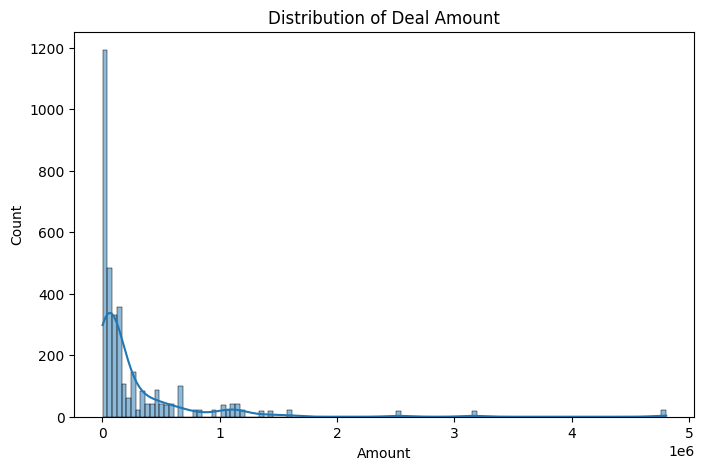

In [3]:
if not df_won.empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_won['Amount'], kde=True)
    plt.title('Distribution of Deal Amount')
    plt.show()
else:
    print("No data found for Closed Won opportunities.")

## 3. Feature Analysis vs Target

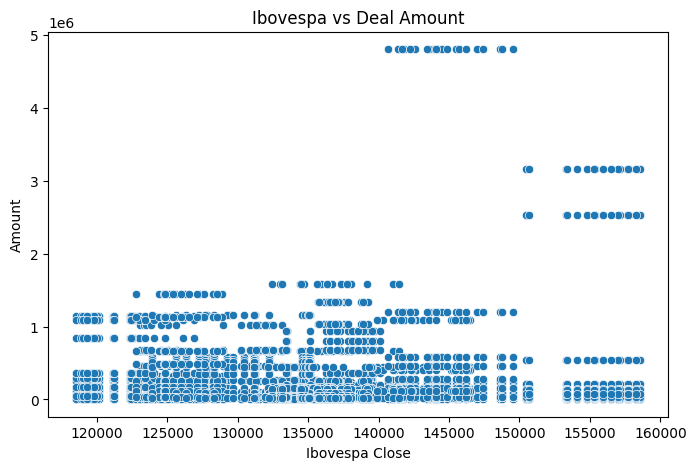

In [4]:
if not df_won.empty:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='Close', y='Amount', data=df_won)
    plt.xlabel('Ibovespa Close')
    plt.title('Ibovespa vs Deal Amount')
    plt.show()

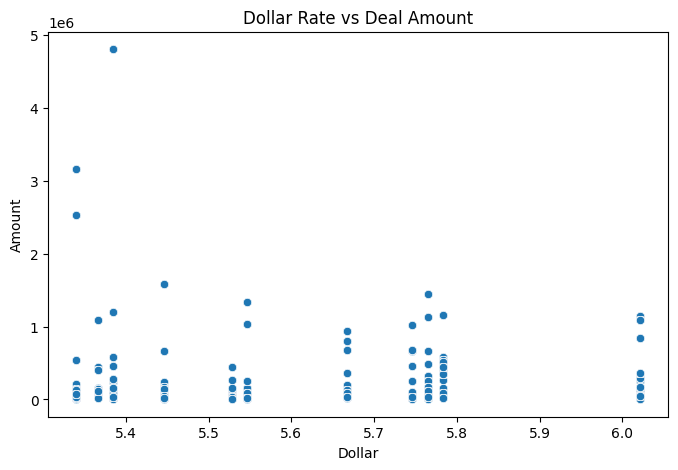

In [5]:
if not df_won.empty:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='Dollar', y='Amount', data=df_won)
    plt.title('Dollar Rate vs Deal Amount')
    plt.show()

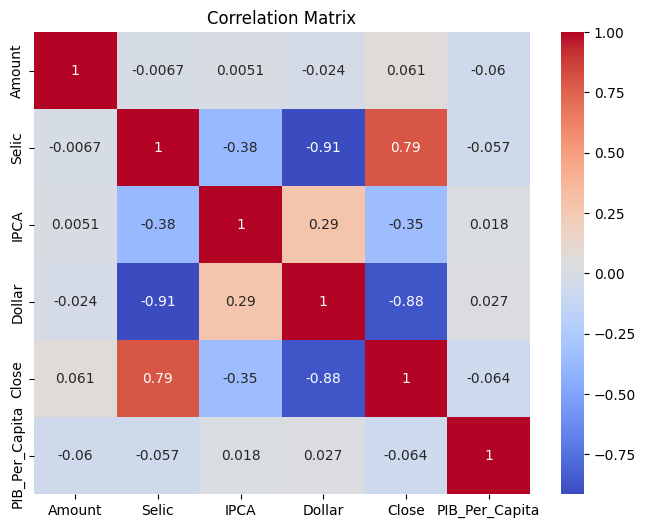

In [6]:
if not df_won.empty:
    cols = ['Amount', 'Selic', 'IPCA', 'Dollar', 'Close', 'PIB_Per_Capita']
    corr = df_won[cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

## 4. Final Analysis & Conclusions

Based on the analysis of **3,530 Won Opportunities**, here are the answers to the initial questions:

### 1. What is the distribution of Deal Size?
The distribution of `Amount` is **highly skewed to the right**.
- **Mean Amount:** R$ 282,449.59
- **Median Amount:** R$ 87,429.00

This indicates that while the majority of deals are below R$ 100k, there are significant high-value outliers pulling the average up. Any regression model will likely need to handle this skewness (e.g., by predicting `log(Amount)`).

### 2. Is there a correlation between Market Indicators (Ibovespa) and Deal Size?
**No significant correlation was found.**
- Correlation with `Close` (Ibovespa): **0.06**

The stock market performance does not appear to be a direct driver of individual deal sizes in this dataset.

### 3. Does the Dollar rate affect the amount?
**No significant correlation was found.**
- Correlation with `Dollar`: **-0.02**

Fluctuations in the exchange rate do not show a linear relationship with the closed deal amounts.